# Wine Quality Analysis
| **Column Name**          | **Description (in simple terms)**                                                   | **Insight / Importance**                                                                                |
| ------------------------ | ----------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------- |
| **fixed acidity**        | The amount of non-volatile acids (like tartaric acid) that do not evaporate easily. | Affects wine taste and stability — too high can make the wine taste sour.                               |
| **volatile acidity**     | The amount of acids that can evaporate easily (mainly acetic acid).                 | High levels give an unpleasant vinegar taste — negatively affects quality.                              |
| **citric acid**          | Adds freshness and flavor to wine.                                                  | Small amounts can make wine taste crisp; too much can be artificial.                                    |
| **residual sugar**       | The amount of sugar left after fermentation.                                        | Determines sweetness — wines with less sugar are typically drier.                                       |
| **chlorides**            | Represents the amount of salt in the wine.                                          | Too high can give a salty or unpleasant taste — lower is better.                                        |
| **free sulfur dioxide**  | Part of total SO₂ that is active as an antimicrobial and antioxidant.               | Helps preserve freshness but excessive levels can cause strong odor.                                    |
| **total sulfur dioxide** | Total amount of free + bound SO₂.                                                   | High levels can affect aroma; excessive SO₂ can reduce quality.                                         |
| **density**              | The mass per unit volume of wine (g/cm³).                                           | Indicates sugar and alcohol content — higher density often means more sugar.                            |
| **pH**                   | Measures the acidity level of the wine.                                             | Lower pH = more acidic; typical values are between 2.8 and 4.0.                                         |
| **sulphates**            | Additives that act as antioxidants and preservatives.                               | Positively related to quality — moderate levels improve wine stability.                                 |
| **alcohol**              | Percentage of alcohol content in wine.                                              | One of the strongest indicators of quality — higher alcohol often means better fermentation and flavor. |
| **quality**              | Score between 0 and 10 given by wine experts.                                       | This is the **target variable** we aim to predict.                                                      |
| **good**                 | A derived binary column (e.g., 1 = good quality, 0 = not good).                     | Used for classification models (predicting good/bad quality).                                           |
| **color**                | Type of wine: red (0) or white (1).                                                 | Helps compare quality differences between red and white wines.                                          |


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from  sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

In [2]:
wine_df=pd.read_csv("winequality.csv")

### Exploratory Data Analysis

In [3]:
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,red


In [4]:
wine_df.shape

(6497, 14)

In [5]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  good                  6497 non-null   int64  
 13  color                 6497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 710.7+ KB


In [7]:
# checking for the Duplicates
wine_df.duplicated().sum()

1177

In [8]:
# Dropping the Duplicates
print(f"Before dropping Duplicates shape of data : {wine_df.shape}")
wine_df=wine_df.drop_duplicates()
print(f"After dropping the duplicates shape of data : {wine_df.shape}")

Before dropping Duplicates shape of data : (6497, 14)
After dropping the duplicates shape of data : (5320, 14)


In [9]:
wine_df.duplicated().sum()

0

In [10]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677,0.189662
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772,0.392070
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000,0.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


### Univariate Ananlysis

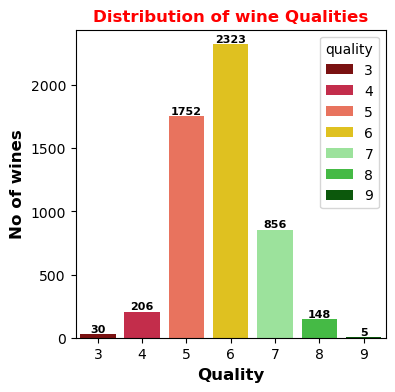

In [11]:
colors = ['#8B0000',  # Quality 3 - Dark Red
          '#DC143C',  # Quality 4 - Crimson
          '#FF6347',  # Quality 5 - Tomato
          '#FFD700',  # Quality 6 - Gold
          '#90EE90',  # Quality 7 - Light Green
          '#32CD32',  # Quality 8 - Lime Green
          '#006400']  # Quality 9 - Dark Green

plt.figure(figsize=(4,4))
ax=sns.countplot(x=wine_df["quality"],palette=colors,hue=wine_df["quality"])
for container in ax.containers:
    ax.bar_label(container,fontsize=8,fontweight="heavy")
plt.xlabel("Quality",fontsize=12,fontweight="heavy")
plt.ylabel("No of wines",fontsize=12,fontweight="heavy")
plt.title("Distribution of wine Qualities",fontweight="heavy",color="red")
plt.show()

## OBSERVATIONS : 

--> Most of the wines are clustered in the "average" quality scores of 5 (1788) and 6 (2416)

Key Insight: Our target variable, quality, is highly imbalanced. We have very few samples for the low-quality (3, 4) and high-quality (8, 9) scores.

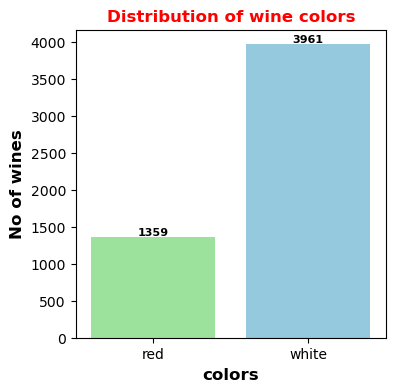

In [12]:
colors=["lightgreen","skyblue"]
plt.figure(figsize=(4,4))
ax=sns.countplot(x=wine_df["color"],palette=colors,hue=wine_df["color"])
for container in ax.containers:
    ax.bar_label(container,fontsize=8,fontweight="heavy")
plt.xlabel("colors",fontsize=12,fontweight="heavy")
plt.ylabel("No of wines",fontsize=12,fontweight="heavy")
plt.title("Distribution of wine colors",fontweight="heavy",color="red")
plt.show()

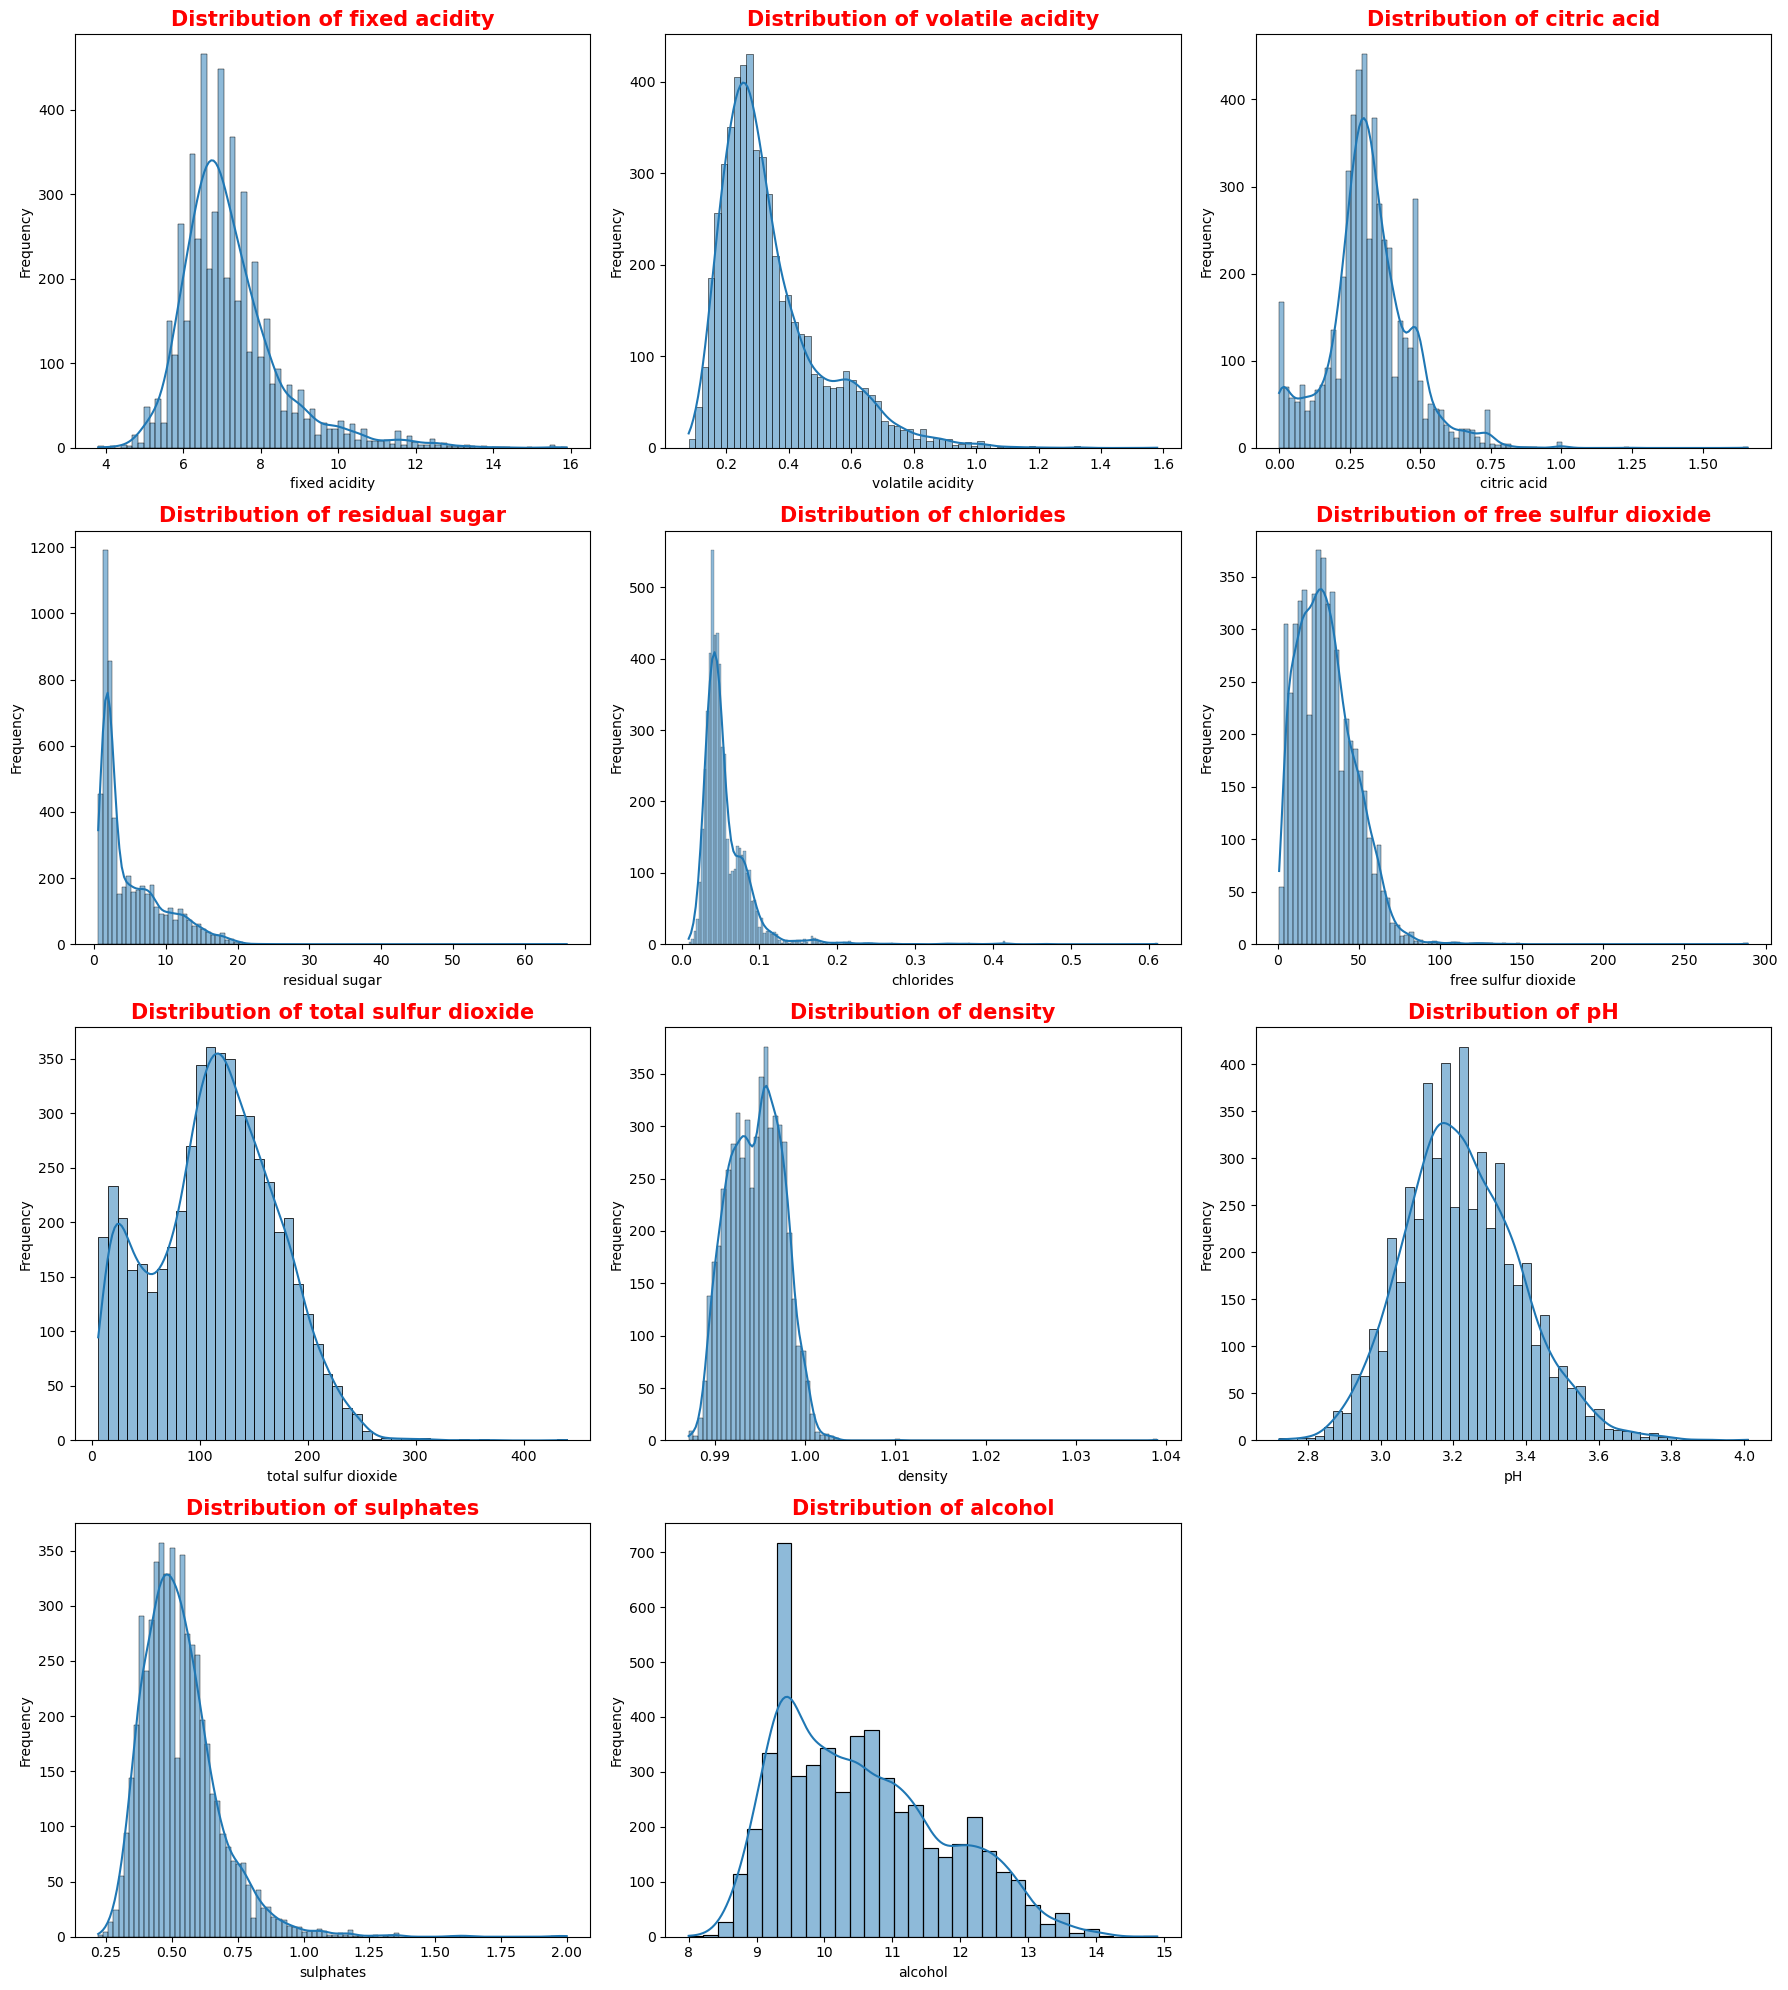

In [13]:
numeric_features = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

plt.figure(figsize=(18,20))
for i , col in enumerate(numeric_features):
    plt.subplot(4,3,i+1)
    sns.histplot(data=wine_df,x=col,kde=True)
    plt.title(f"Distribution of {col}",fontweight="bold",fontsize=15,color="red")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Observation

Most features show slight skewness (e.g., residual sugar, sulphates).

Quality distribution is imbalanced — majority of samples fall in the 5–6 range.

### Univaraite Observations : 
Our target quality is imbalanced (mostly 5s and 6s).

Our feature color is imbalanced (mostly white wine).

Our numeric features are skewed and on different scales.

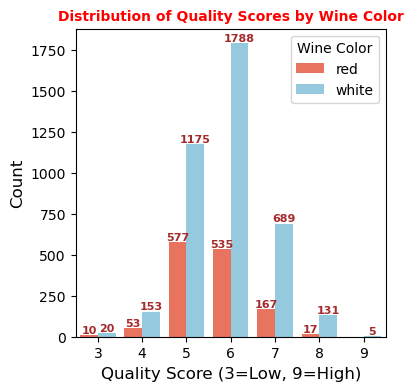

In [14]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x=wine_df["quality"],hue=wine_df["color"],palette=["tomato","skyblue"])
for container in ax.containers:
    ax.bar_label(container,fontweight="bold",color="brown",fontsize=8)
plt.title('Distribution of Quality Scores by Wine Color', fontsize=10, fontweight='bold',color="red")
plt.xlabel('Quality Score (3=Low, 9=High)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Wine Color', loc='upper right')
plt.show()

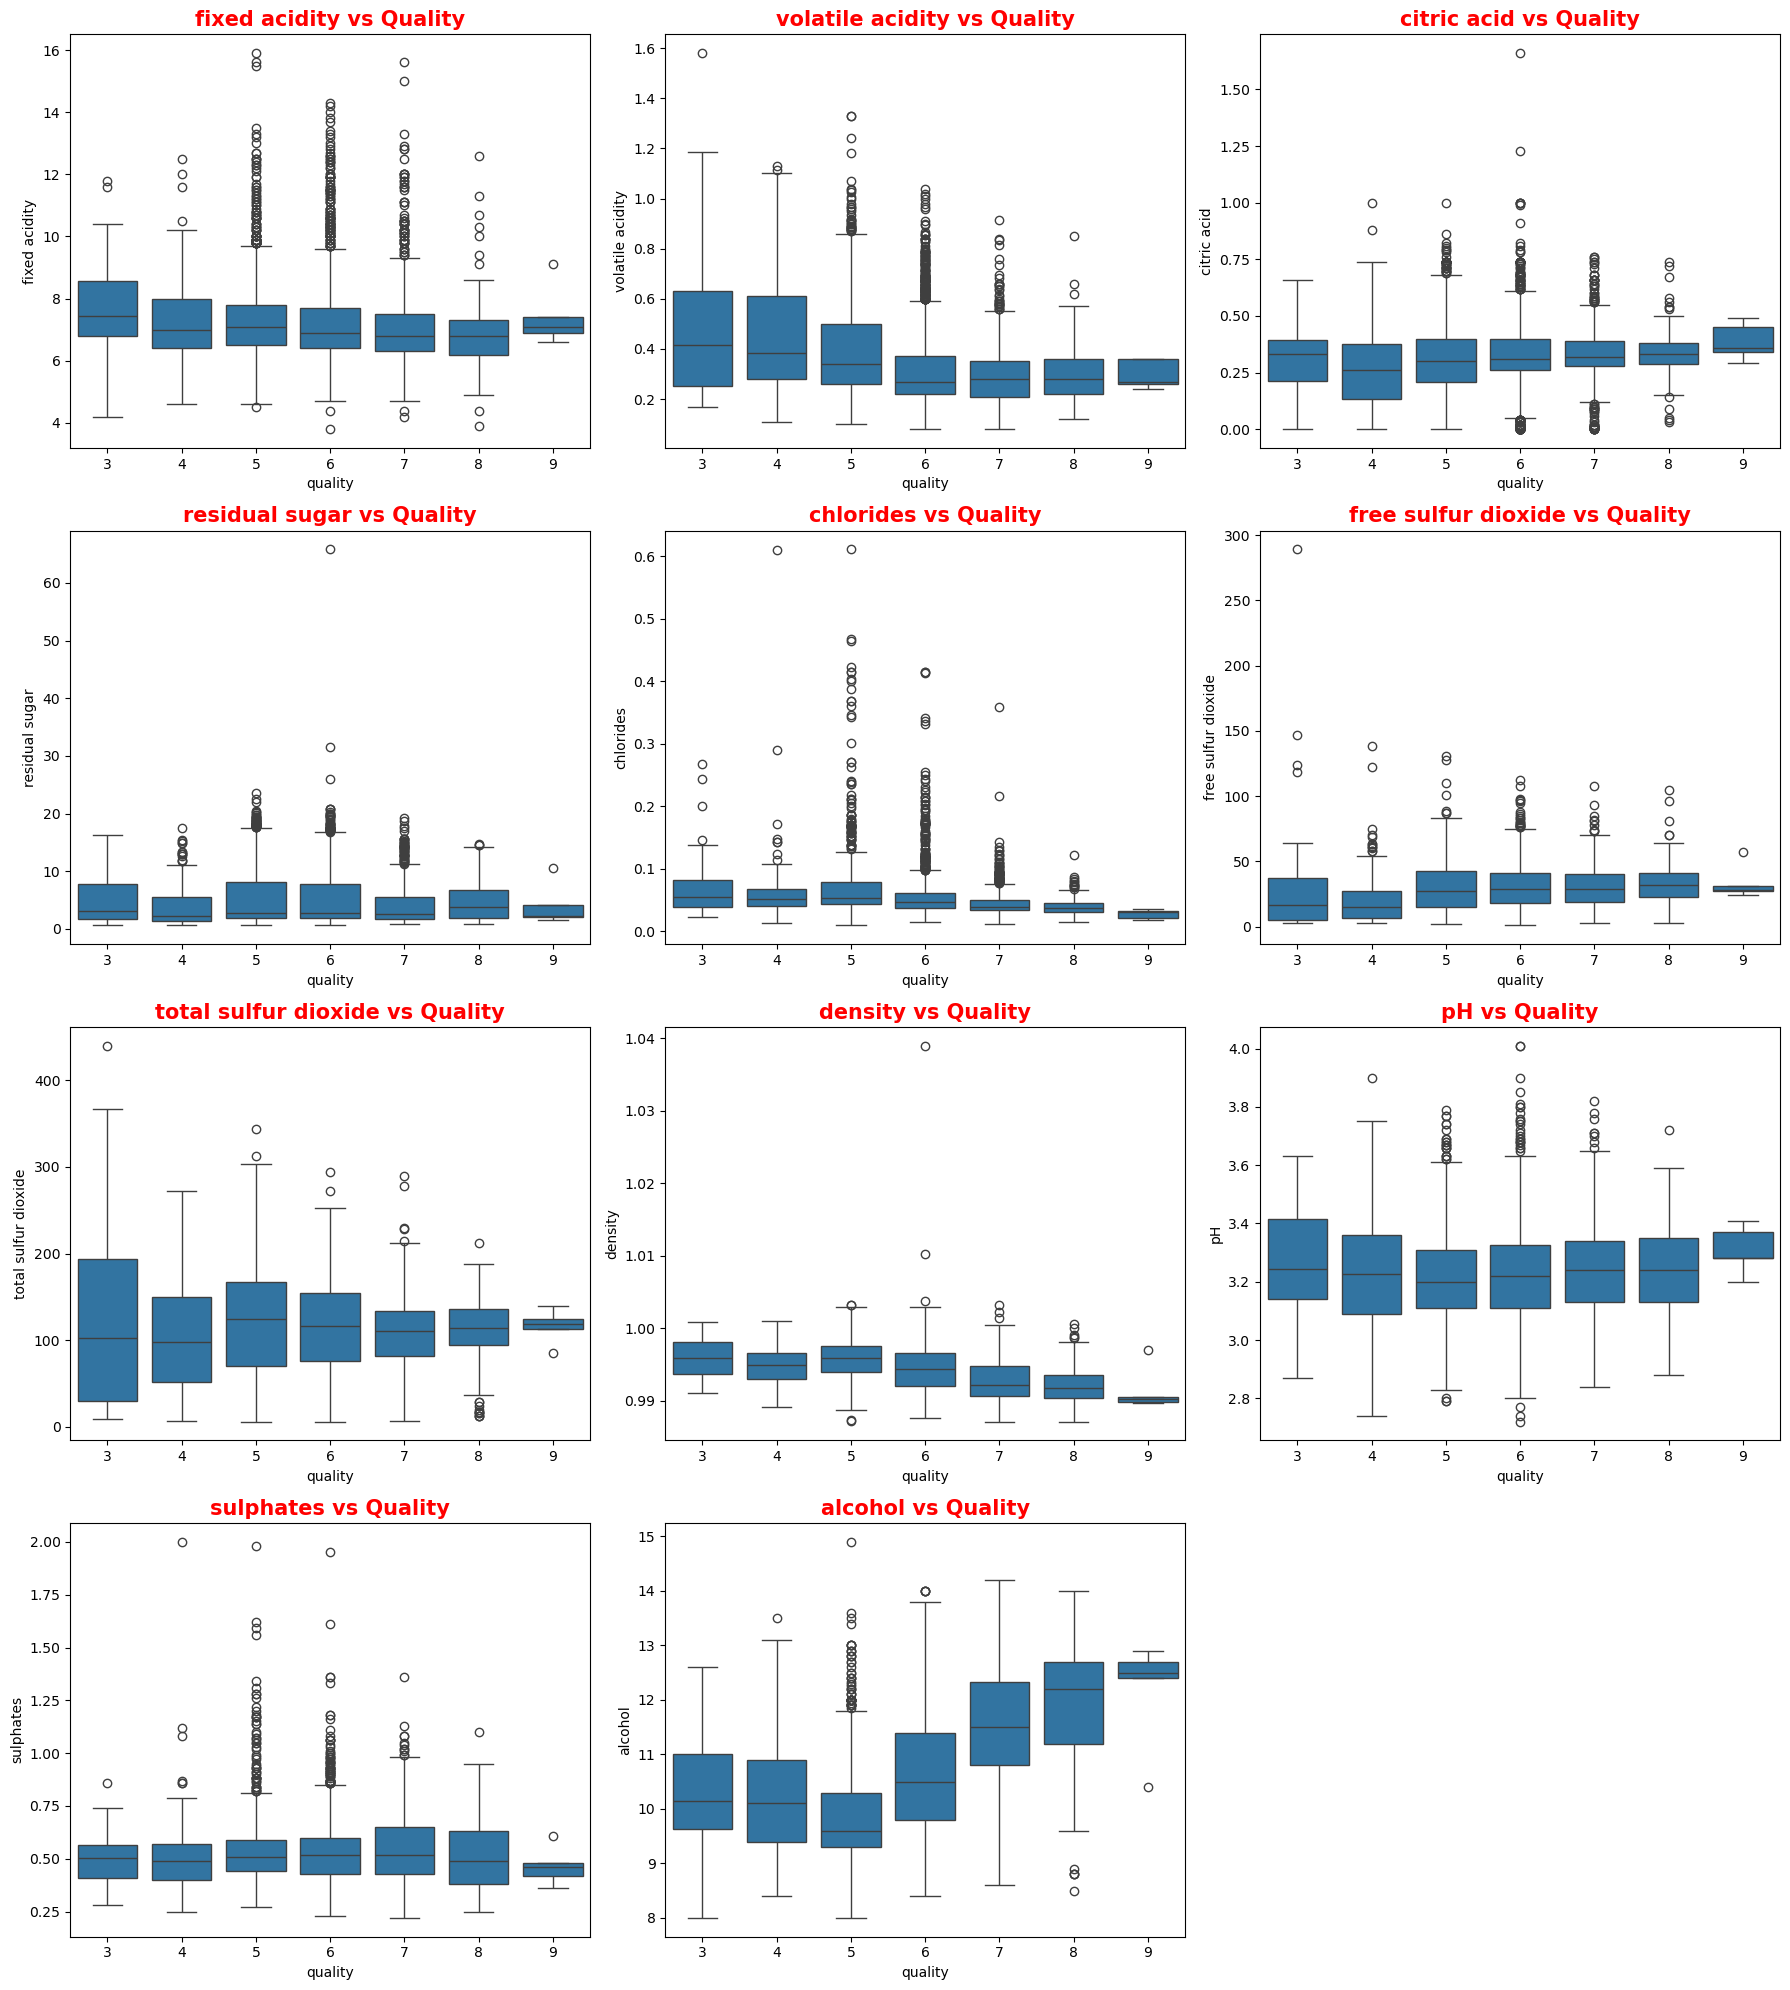

In [15]:
numeric_features = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

plt.figure(figsize=(18,20))
for i , col in enumerate(numeric_features):
    plt.subplot(4,3,i+1)
    sns.boxplot(data=wine_df,x=wine_df["quality"],y=col)
    plt.title(f"{col} vs Quality",fontweight="bold",fontsize=15,color="red")
    plt.ylabel(col)
plt.tight_layout()
plt.show()


### Observation:

Alcohol and sulphates increase with quality.

Volatile acidity, chlorides, and density decrease as quality increases.

Many outliers exist, especially in volatile acidity and residual sugar.

Because outliers help you understand how chemical properties differ among wine types and qualities.

In [16]:
le=LabelEncoder()
df_encoded=wine_df
df_encoded["color"]=le.fit_transform(df_encoded["color"])

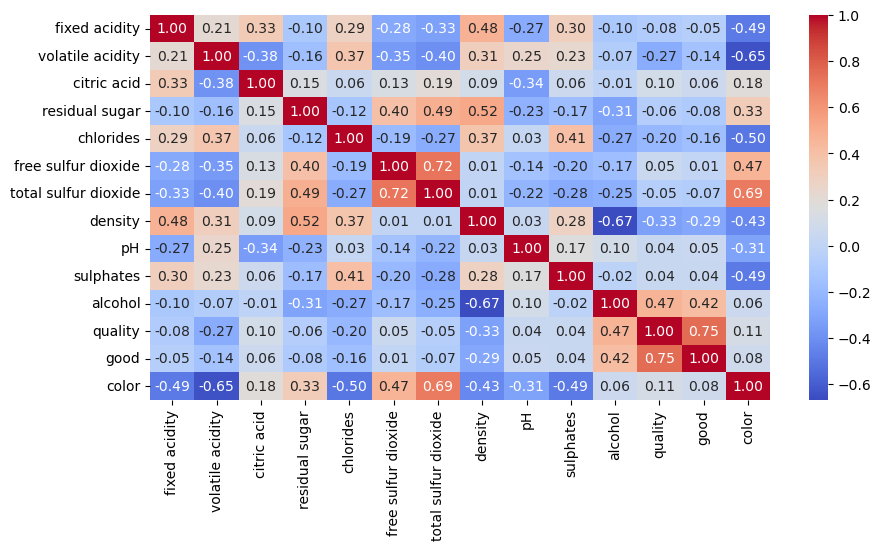

In [17]:
corr_matrix = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df_encoded.select_dtypes(include=['float64', 'int64']).drop(columns=['quality', 'good'])
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data


,Feature,VIF
0,fixed acidity,57.503297
1,volatile acidity,8.856584
2,citric acid,9.404055
3,residual sugar,3.320388
4,chlorides,5.298323
5,free sulfur dioxide,8.217477
6,total sulfur dioxide,14.202293
7,density,936.140550
8,pH,587.436005
9,sulphates,18.511697


### Final Observations of EDA
Target: quality (imbalanced, with rare high/low scores).

Key Inputs: color (categorical), plus 11 numeric features.

Key Challenges:

Imbalanced target (quality) - We must use stratify in our split.

Skewed features (residual sugar, etc.) - We must use a log_transform.

Different scales (pH vs. total sulfur dioxide) - We must use a StandardScaler.


In [32]:
df_encoded.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good,color
5675,7.4,0.37,0.26,9.60,0.050,33.0,134.0,0.99608,3.13,0.46,10.4,5,0,1
4072,6.0,0.29,0.21,15.55,0.043,20.0,142.0,0.99658,3.11,0.54,10.1,6,0,1
5827,6.2,0.29,0.23,12.40,0.048,33.0,201.0,0.99612,3.11,0.56,9.9,6,0,1
126,8.2,1.33,0.00,1.70,0.081,3.0,12.0,0.99640,3.53,0.49,10.9,5,0,0
84,6.3,0.30,0.48,1.80,0.069,18.0,61.0,0.99590,3.44,0.78,10.3,6,0,0


###  Define Features (X) and Target (y)

In [33]:
# Separate features and target
X = df_encoded.drop(["quality","good","density","pH"], axis=1)
y = df_encoded['quality']

print("="*60)
print("CLASS DISTRIBUTION")
print("="*60)
print(y.value_counts().sort_index())
print(f"\nTotal samples: {len(y)}")

CLASS DISTRIBUTION
quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64

Total samples: 5320


In [34]:
# This significantly improves accuracy for imbalanced wine quality data
# Quality >= 6 is "Good", < 6 is "Bad"

y_binary = (y >= 6).astype(int)
print(f"\nBinary classification distribution:")
print(f"Bad (0):  {(y_binary == 0).sum()} samples")
print(f"Good (1): {(y_binary == 1).sum()} samples")


Binary classification distribution:
Bad (0):  1988 samples
Good (1): 3332 samples


In [35]:
X_train, X_test, y_train, y_test = train_test_split( X, y_binary, test_size=0.3, random_state=42,stratify=y_binary)  # Maintain class distribution)

In [36]:
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 3724 samples
Test set: 1596 samples


In [37]:
NUMERIC_FEATURES_LOG = ['residual sugar', 'chlorides', 'free sulfur dioxide', 
                        'total sulfur dioxide', 'sulphates']

FEATURES_TO_SCALE = ['fixed acidity', 'volatile acidity', 'citric acid', 
                     'residual sugar', 'chlorides', 'free sulfur dioxide',
                     'total sulfur dioxide', 'sulphates', 'alcohol']

In [38]:
# Initialize scaler
scaler = StandardScaler()

# Process TRAINING data
X_train_processed = X_train.copy()

# Apply log transformation to reduce skewness
X_train_processed[NUMERIC_FEATURES_LOG] = np.log1p(X_train_processed[NUMERIC_FEATURES_LOG])

# Fit scaler on training data and transform
scaler.fit(X_train_processed[FEATURES_TO_SCALE])
X_train_processed[FEATURES_TO_SCALE] = scaler.transform(X_train_processed[FEATURES_TO_SCALE])

In [39]:
X_test_processed = X_test.copy()

# Apply same log transformation
X_test_processed[NUMERIC_FEATURES_LOG] = np.log1p(X_test_processed[NUMERIC_FEATURES_LOG])

# Transform using fitted scaler (DO NOT FIT AGAIN)
X_test_processed[FEATURES_TO_SCALE] = scaler.transform(X_test_processed[FEATURES_TO_SCALE])

In [46]:
def train_evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train and evaluate a classification model
    """
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Confusion Matrix
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(f"\nTrue Negatives:  {cm[0][0]}")
    print(f"False Positives: {cm[0][1]}")
    print(f"False Negatives: {cm[1][0]}")
    print(f"True Positives:  {cm[1][1]}")
    
    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Bad Wine', 'Good Wine'], zero_division=0))
    
    # Feature Importances
    if hasattr(model, "feature_importances_"):
        print(f"\nTop 10 Feature Importances:")
        feature_imp = sorted(
            zip(X_train.columns, model.feature_importances_),
            key=lambda x: x[1],
            reverse=True
        )
        for i, (feature, importance) in enumerate(feature_imp[:10], 1):
            print(f"   {i:2d}. {feature:<25} -> {importance:.4f}")
    
    return model, y_pred, accuracy, f1

In [47]:
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=1000,
        C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=11,
        weights='distance'
    ),
    'SVM (Support Vector Machine)': SVC(
        random_state=42,
        class_weight='balanced',
        probability=True  # Good for consistency, but slower
    )
}

In [48]:
results = {}

# Train each model
for name, model in models.items():
    trained_model, y_pred, acc, f1 = train_evaluate_model(
        model, 
        X_train_processed,
        X_test_processed,
        y_train,
        y_test,
        name
    )
    
    results[name] = {
        'model': trained_model,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_score': f1
    }



Model: Logistic Regression
Accuracy:  0.7475 (74.75%)
Precision: 0.8350
Recall:    0.7440
F1-Score:  0.7869

Confusion Matrix:
[[449 147]
 [256 744]]

True Negatives:  449
False Positives: 147
False Negatives: 256
True Positives:  744

Classification Report:
              precision    recall  f1-score   support

    Bad Wine       0.64      0.75      0.69       596
   Good Wine       0.84      0.74      0.79      1000

    accuracy                           0.75      1596
   macro avg       0.74      0.75      0.74      1596
weighted avg       0.76      0.75      0.75      1596


Model: Decision Tree
Accuracy:  0.7036 (70.36%)
Precision: 0.8133
Recall:    0.6840
F1-Score:  0.7431

Confusion Matrix:
[[439 157]
 [316 684]]

True Negatives:  439
False Positives: 157
False Negatives: 316
True Positives:  684

Classification Report:
              precision    recall  f1-score   support

    Bad Wine       0.58      0.74      0.65       596
   Good Wine       0.81      0.68      0.74      1

In [49]:

# ============================================================
#  MODEL COMPARISON
# ============================================================

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY ( WITHOUT [ DENSTIY , PH ] COLUMNS)")
print("="*60)
print(f"{'Model':<25} | {'Accuracy':<10} | {'F1-Score':<10}")
print("-"*60)

for name in results:
    acc = results[name]['accuracy']
    f1 = results[name]['f1_score']
    print(f"{name:<25} | {acc:.4f}     | {f1:.4f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print("="*60)





MODEL COMPARISON SUMMARY ( WITHOUT [ DENSTIY , PH ] COLUMNS)
Model                     | Accuracy   | F1-Score  
------------------------------------------------------------
Logistic Regression       | 0.7475     | 0.7869
Decision Tree             | 0.7036     | 0.7431
Random Forest             | 0.7701     | 0.8123
KNN                       | 0.7513     | 0.8087
SVM (Support Vector Machine) | 0.7600     | 0.7970

🏆 BEST MODEL: Random Forest
   Accuracy: 0.7701 (77.01%)


In [31]:
import numpy as np
import pandas as pd

# New wine data
new_wines = pd.DataFrame({
    'fixed acidity': [7.4, 8.1, 7.9, 6.5],
    'volatile acidity': [0.70, 0.56, 0.48, 0.62],
    'citric acid': [0.00, 0.28, 0.36, 0.15],
    'residual sugar': [1.9, 2.1, 5.2, 3.8],
    'chlorides': [0.076, 0.073, 0.068, 0.055],
    'free sulfur dioxide': [11.0, 17.0, 28.0, 22.0],
    'total sulfur dioxide': [34.0, 60.0, 112.0, 85.0],
    'sulphates': [0.56, 0.62, 0.71, 0.68],
    'alcohol': [9.4, 10.8, 11.2, 12.5],
    'color': [0, 1, 1, 0]  # ADD THIS! 0=red, 1=white (or vice versa)
})

print("New wine samples (with color):")
print(new_wines)
print()

# Use the already trained model and scaler
best_model = results['Random Forest']['model']

# Preprocess (same as training)
NUMERIC_FEATURES_LOG = ['residual sugar', 'chlorides', 'free sulfur dioxide', 
                        'total sulfur dioxide', 'sulphates']
FEATURES_TO_SCALE = ['fixed acidity', 'volatile acidity', 'citric acid', 
                     'residual sugar', 'chlorides', 'free sulfur dioxide',
                     'total sulfur dioxide', 'sulphates', 'alcohol']

new_wines_processed = new_wines.copy()
new_wines_processed[NUMERIC_FEATURES_LOG] = np.log1p(new_wines_processed[NUMERIC_FEATURES_LOG])
new_wines_processed[FEATURES_TO_SCALE] = scaler.transform(new_wines_processed[FEATURES_TO_SCALE])

# Predict
predictions = best_model.predict(new_wines_processed)
probabilities = best_model.predict_proba(new_wines_processed)

# Display results
print("="*80)
print("🍷 WINE QUALITY PREDICTIONS")
print("="*80)

for i in range(len(predictions)):
    quality = "GOOD WINE ✓" if predictions[i] == 1 else "BAD WINE ✗"
    confidence = probabilities[i][predictions[i]] * 100
    wine_type = "Red Wine" if new_wines['color'].iloc[i] == 0 else "White Wine"
    
    print(f"\nWine Sample #{i+1} ({wine_type}):")
    print(f"  Prediction:  {quality}")
    print(f"  Confidence:  {confidence:.2f}%")
    print(f"  Bad Wine:   {probabilities[i][0]*100:.2f}%")
    print(f"  Good Wine:  {probabilities[i][1]*100:.2f}%")
    print("-"*80)

print("="*80)

New wine samples (with color):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            8.1              0.56         0.28             2.1      0.073   
2            7.9              0.48         0.36             5.2      0.068   
3            6.5              0.62         0.15             3.8      0.055   

   free sulfur dioxide  total sulfur dioxide  sulphates  alcohol  color  
0                 11.0                  34.0       0.56      9.4      0  
1                 17.0                  60.0       0.62     10.8      1  
2                 28.0                 112.0       0.71     11.2      1  
3                 22.0                  85.0       0.68     12.5      0  

🍷 WINE QUALITY PREDICTIONS

Wine Sample #1 (Red Wine):
  Prediction:  BAD WINE ✗
  Confidence:  88.35%
  Bad Wine:   88.35%
  Good Wine:  11.65%
--------------------------------------------------------------